In [9]:
import random
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import matplotlib.patches as mpatches
from PIL import Image as PILImage
from IPython.display import display, Image as DisplayImage, Markdown
from io import BytesIO

# ============================================================
# Configuration
# ============================================================
CHIP_DIR = '/explore/nobackup/projects/pix4dcloud/aliewehr/chipTests/newShapeChips/test6'
N_CHIPS = 5
ABI_BAND = 13
FPS = 1.0


In [10]:
cloud_colors = [
    "#777777",  # -1: missing retrieval
    "#ffffff",  #  0: valid clear
    "#66c2ff",  #  1 cirrus
    "#33a02c",  #  2 altostratus
    "#e31a1c",  #  3 altocumuls
    "#9467bd",  #  4 stratus
    "#8c564b",  #  5 stratocumulus
    "#e377c2",  #  6 cumulus
    "#bcbd22",  #  7 numbostratus
    "#17becf",  #  8 deep convection
]
cloud_cmap = ListedColormap(cloud_colors)
cloud_norm = BoundaryNorm(np.arange(-1.5, 9.5, 1), cloud_cmap.N)

def draw_legend():
    cloud_legend_data = [
        ("-1", "#777777", "Missing Retrieval"),
        ("0", "#ffffff", "Valid Clear"),
        ("1", "#66c2ff", "Cirrus"),
        ("2", "#33a02c", "Altostratus"),
        ("3", "#e31a1c", "Altocumulus"),
        ("4", "#9467bd", "Stratus"),
        ("5", "#8c564b", "Stratocumulus"),
        ("6", "#e377c2", "Cumulus"),
        ("7", "#bcbd22", "Nimbostratus"),
        ("8", "#17becf", "Deep Convection"),
    ]
    patches = []
    for val, hex_val, name in cloud_legend_data:
        is_white = hex_val == "#ffffff"
        patches.append(mpatches.Patch(
            color=hex_val, label=f"{val}: {name}",
            edgecolor="black" if is_white else None,
            linewidth=0.5 if is_white else 0
        ))
    fig, ax = plt.subplots(figsize=(6, 4.5), dpi=150)
    ax.axis("off")
    ax.legend(handles=patches, loc="center", frameon=True, facecolor="#f9f9f9", edgecolor="#dddddd", fontsize=10, title="Cloud Color Legend", title_fontsize=11)
    plt.tight_layout()
    plt.show()


In [11]:
def track_distance_km(latitude, longitude):
    latitude = np.deg2rad(latitude)
    longitude = np.deg2rad(longitude)
    if len(latitude) < 2:
        return np.zeros(len(latitude))
    delta_latitude = np.diff(latitude)
    delta_longitude = np.diff(longitude)
    haversine = (
        np.sin(delta_latitude / 2) ** 2
        + np.cos(latitude[:-1]) * np.cos(latitude[1:])
        * np.sin(delta_longitude / 2) ** 2
    )
    segments = 2 * 6371.0 * np.arcsin(np.sqrt(haversine))
    return np.concatenate([[0.0], np.cumsum(segments)])

def band_limits(chip, band_index):
    values = chip[..., band_index]
    valid = values[np.isfinite(values)]
    if valid.size == 0:
        return 0.0, 1.0
    lower, upper = np.percentile(valid, [2, 98])
    if np.isclose(lower, upper):
        upper = lower + 1.0
    return float(lower), float(upper)


In [12]:
def draw_abi_1d(axis, sample, frame, band_index, limits):
    band_1d = sample["ABI/chip"][frame, :, 0, band_index]
    distance = track_distance_km(sample["CloudSat/latitude"], sample["CloudSat/longitude"])
    maximum_distance = max(float(distance[-1]), 1e-6)
    
    band_2d = band_1d[np.newaxis, :]
    lower, upper = limits
    
    axis.imshow(
        band_2d, origin="lower", aspect="auto",
        extent=[0, maximum_distance, 0, 1],
        cmap='gray', vmin=lower, vmax=upper
    )
    
    offset = int(sample["ABI/offsets_minutes"][frame])
    scan_time = str(sample["ABI/scan_times"][frame])
    valid = int(sample["ABI/valid_mask"][frame])
    
    axis.set_title(f"ABI C{ABI_BAND:02d} (1D Transect) | {offset:+d} min | valid={valid}\n{scan_time}")
    axis.set_xlabel("Distance along track (km)")
    axis.set_yticks([])
    axis.set_ylabel("Radiance")

def draw_cloudsat_mask(axis, sample):
    mask = sample["CloudSat/cloud_class"]
    distance = track_distance_km(sample["CloudSat/latitude"], sample["CloudSat/longitude"])
    maximum_distance = max(float(distance[-1]), 1e-6)
    
    axis.imshow(
        mask.T, origin="lower", aspect="auto", interpolation="nearest",
        extent=[0, maximum_distance, 0, mask.shape[1] * 0.5],
        cmap=cloud_cmap, norm=cloud_norm,
    )
    axis.set_xlabel("Distance along track (km)")
    axis.set_ylabel("Altitude (km)")
    axis.set_ylim(0, 20)


In [13]:
def make_gif(path):
    sample = np.load(path, allow_pickle=True)
    band_index = ABI_BAND - 1
    limits = band_limits(sample["ABI/chip"], band_index)
    fileName = path.split('/')[-1]
    frames = []
    
    for frame in range(sample["ABI/chip"].shape[0]):
        figure, axes = plt.subplots(2, 1, figsize=(14, 8), dpi=90, gridspec_kw={'height_ratios': [1, 3]})
        draw_abi_1d(axes[0], sample, frame, band_index, limits)
        draw_cloudsat_mask(axes[1], sample)
        figure.suptitle(fileName, fontsize=10)
        figure.tight_layout(rect=(0, 0, 1, 0.95))
        figure.canvas.draw()
        image = PILImage.fromarray(np.asarray(figure.canvas.buffer_rgba())).convert("RGB")
        frames.append(image)
        plt.close(figure)
        
    buffer = BytesIO()
    frames[0].save(
        buffer, format="GIF", save_all=True, append_images=frames[1:],
        duration=int(1000 / FPS), loop=0, disposal=2, optimize=False,
    )
    return buffer.getvalue()


Displaying 5 random chips of 143 total.


/explore/nobackup/people/aliewehr/.nccstmp/ipykernel_507089/1986311909.py:32: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches.append(mpatches.Patch(


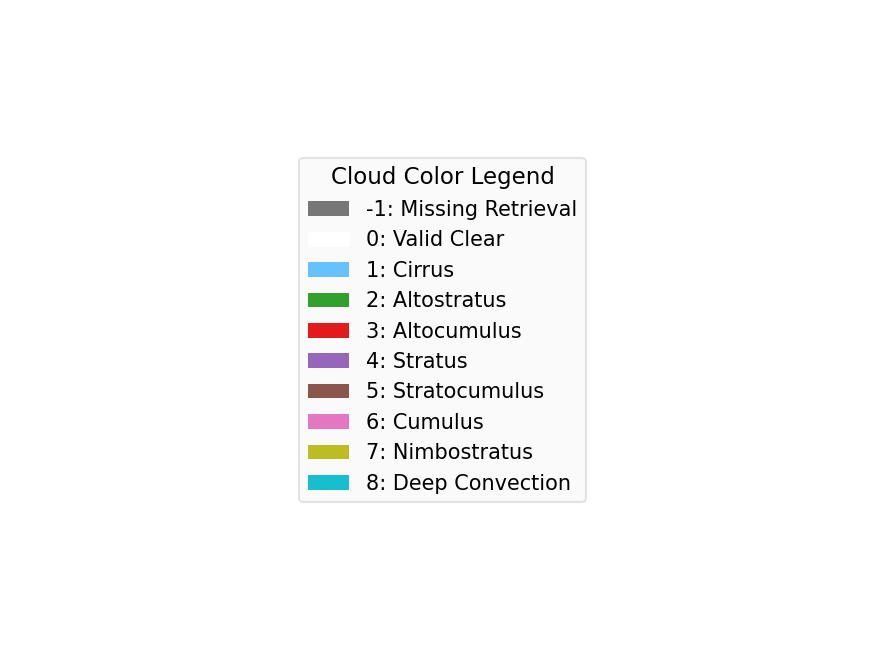

### Chip 1/5
**GOES16_east_abi_cloudsat_20190410T200701Z_orbit68984_r5299_c3303_p18616_len512.npz**

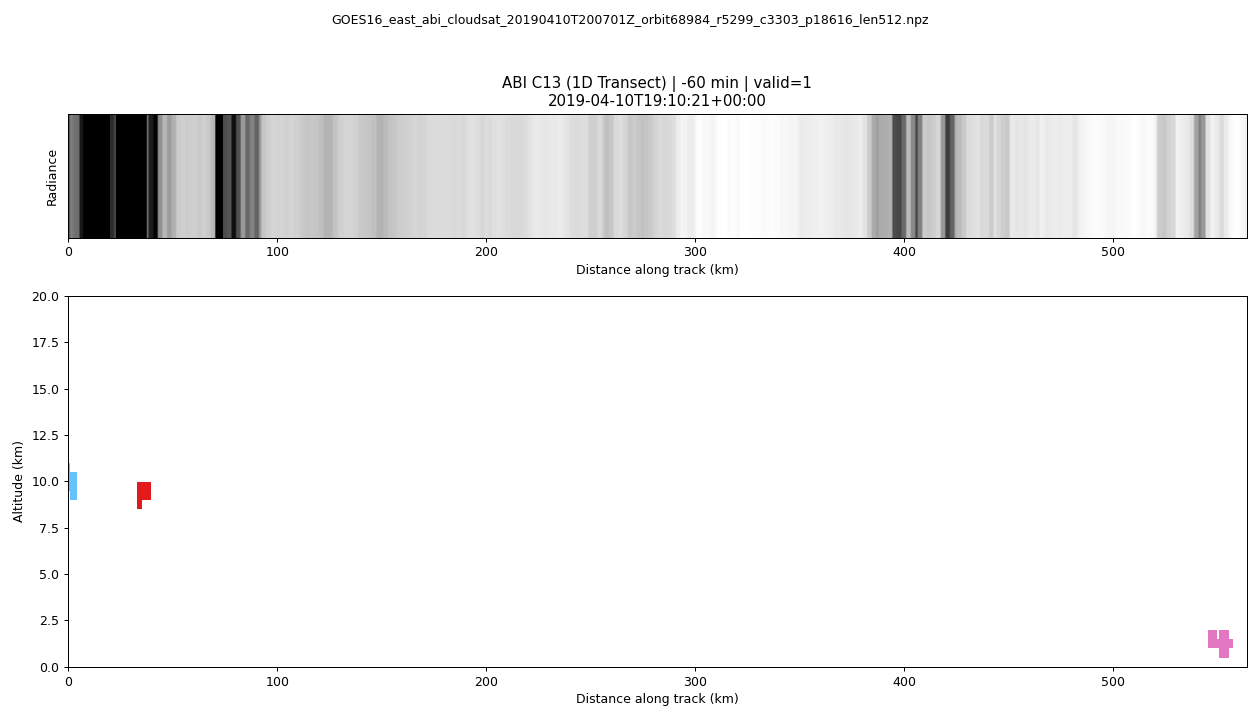

### Chip 2/5
**GOES16_east_abi_cloudsat_20190411T172434Z_orbit68997_r6619_c7788_p17356_len512.npz**

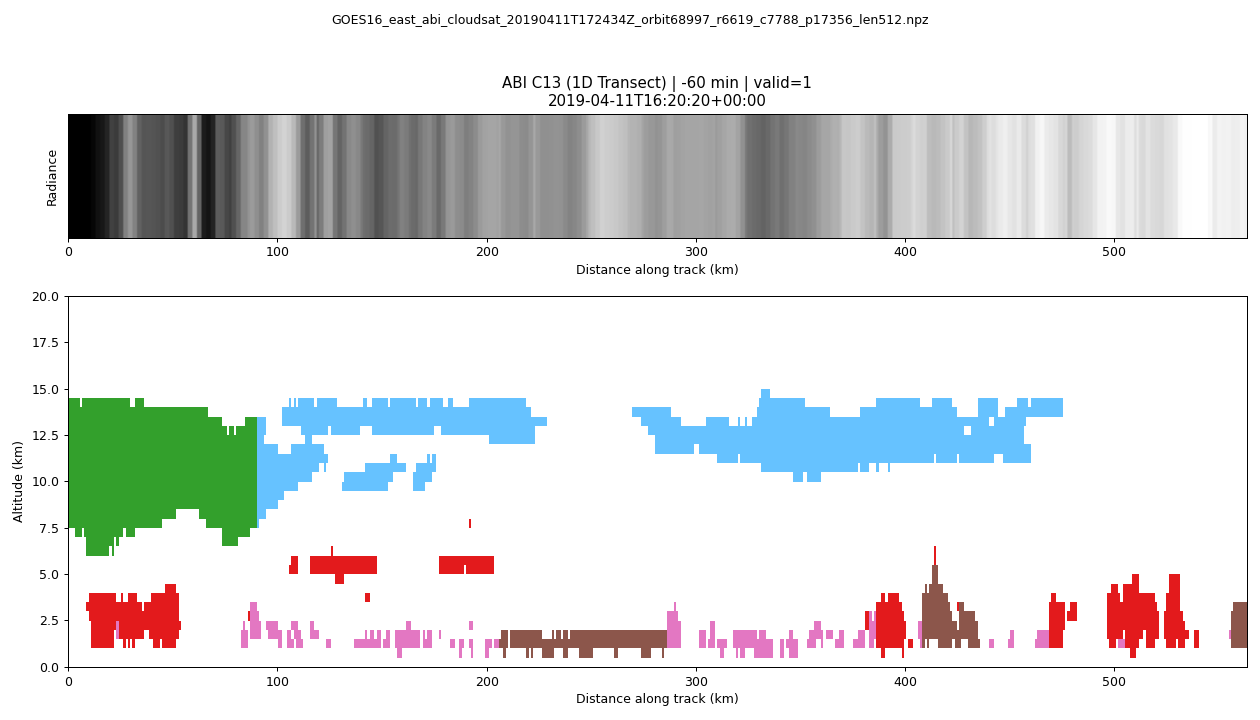

### Chip 3/5
**GOES16_east_abi_cloudsat_20190410T183150Z_orbit68983_r3969_c5671_p19876_len512.npz**

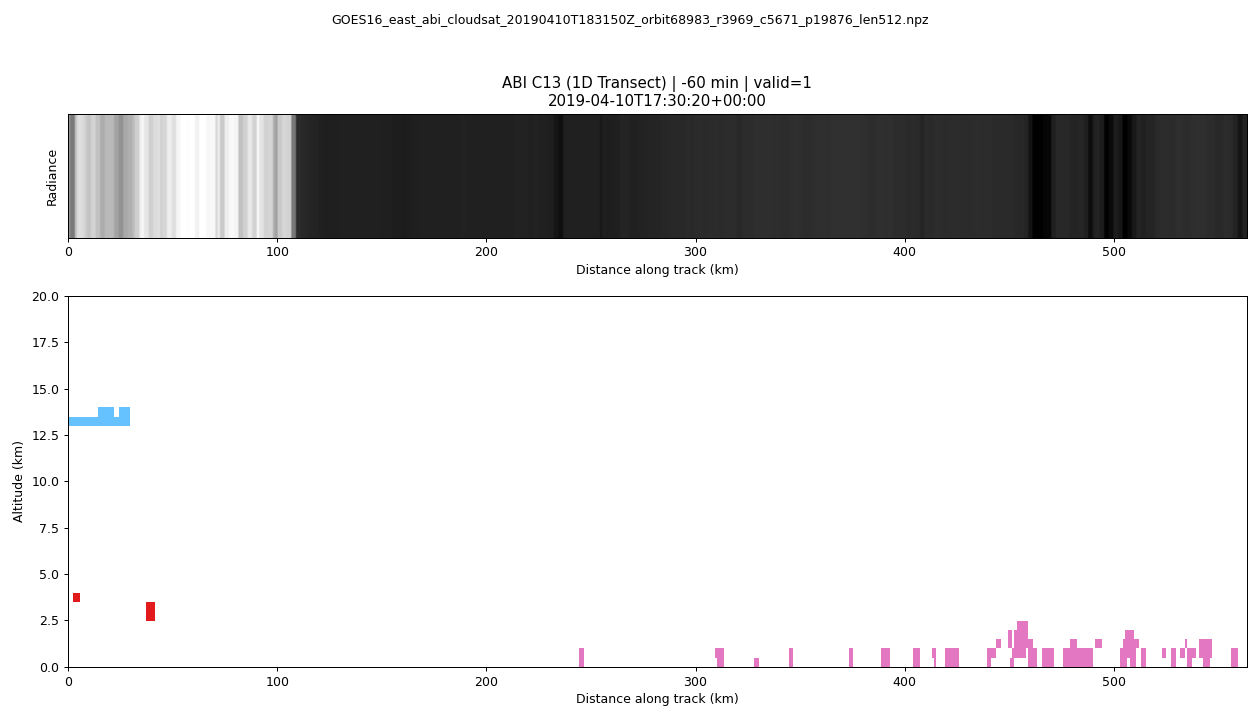

### Chip 4/5
**GOES16_east_abi_cloudsat_20190410T182341Z_orbit68983_r7183_c6338_p16816_len512.npz**

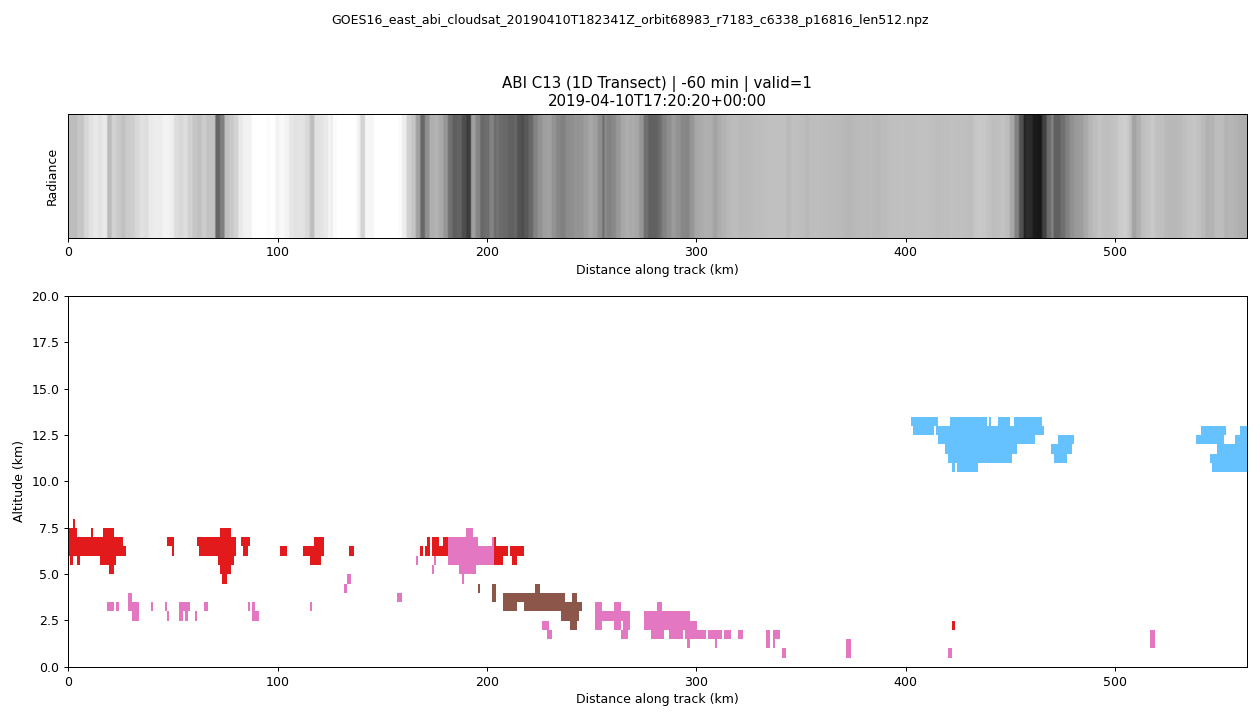

### Chip 5/5
**GOES16_east_abi_cloudsat_20190410T201344Z_orbit68984_r2784_c3069_p21136_len512.npz**

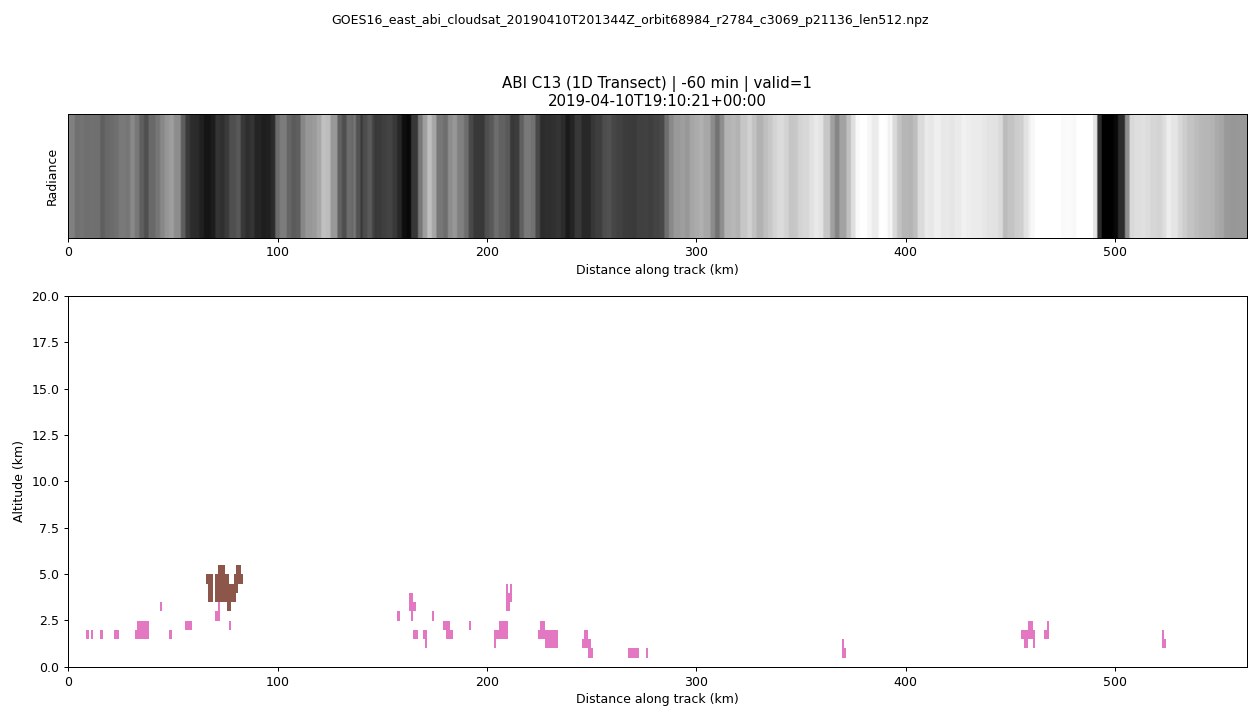

In [14]:
chip_files = sorted(glob.glob(os.path.join(CHIP_DIR, "*.npz")))
if not chip_files:
    raise FileNotFoundError(f"No NPZ files found in {CHIP_DIR}")

# Pick random chips
selected_files = random.sample(chip_files, k=min(N_CHIPS, len(chip_files)))
print(f"Displaying {len(selected_files)} random chips of {len(chip_files)} total.")

draw_legend()

for chip_number, path in enumerate(selected_files, start=1):
    display(Markdown(f"### Chip {chip_number}/{len(selected_files)}\n**{os.path.basename(path)}**"))
    gif_data = make_gif(path)
    display(DisplayImage(data=gif_data, format="gif"))


In [15]:
!pwd

/panfs/ccds02/nobackup/people/aliewehr/satvision-pix4d/satvision_pix4d/preprocessing/cloudsat_abi/updatedShape/visualization
